<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/TP_IA_RL_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea 5 IA: regresión logística y métricas de clasificación.**




**Alumno: Ancarani Juan Diego.**

In [ ]:
#Importaciones para calculos generales.
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Importaciones para modelaje
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#'PrimaIndiansDiabetes'
csv = "diabetes.data.csv"
df = pd.read_csv(csv, header=None)

#Le asignamos nombres a las columnas numericas
columns_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'insulin', 'BMI', 'DiabetesPedigree', 'Age', 'OutCome']

df = pd.read_csv(csv, names = columns_names)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,insulin,BMI,DiabetesPedigree,Age,OutCome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
patients_count = df['OutCome'].value_counts()

print(f'Pacientes registradas: {patients_count[0] + patients_count[1]}')
print(f'Pacientes sanas: {patients_count[0]}')
print(f'Pacientes diabéticas: {patients_count[1]}')

Pacientes registradas: 768
Pacientes sanas: 500
Pacientes diabéticas: 268


In [ ]:
#Eliminar columna 'Outcome' →  pq caracteriza si tiene diabetes o no.

X = df.drop('OutCome', axis = 1)
y = df['OutCome'] #variable nueva (la que predecimos)

In [ ]:
#Dividir DataSet (80% Entren., 20% Prueba), luego entrenar usando LinearLogistic

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Le asignamos al modelo un total de 5000 'intentos' para que logre establecer los mejores resultados al predecir.
model = LogisticRegression(l1_ratio = 1, max_iter = 5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

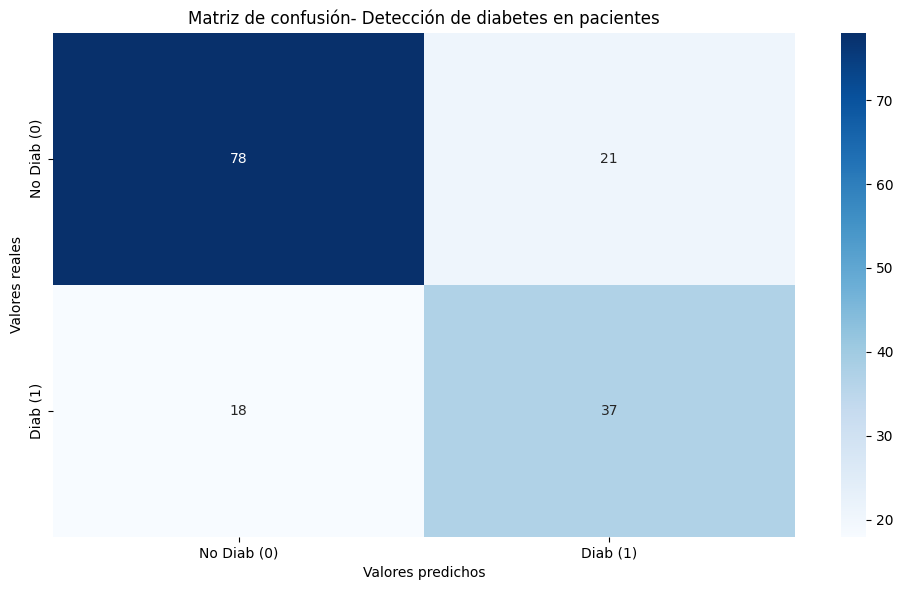

In [ ]:
#Matriz de confusión

Matriz_cf = confusion_matrix(y_test, y_pred )
plt.figure(figsize = (10,6))
sns.heatmap(Matriz_cf, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['No Diab (0)', 'Diab (1)'],
            yticklabels=['No Diab (0)', 'Diab (1)'])
plt.title('Matriz de confusión- Detección de diabetes en pacientes')
plt.ylabel('Valores reales')
plt.xlabel('Valores predichos')

plt.tight_layout()
plt.show()

In [ ]:
#Compartamos la métrica para ver que 'tan bien' clasifica el modelo.

Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred)
Recall = recall_score(y_test, y_pred, average = 'weighted', zero_division=0)
F1 = f1_score(y_test, y_pred, average = 'weighted', zero_division=0)

print(f'Accuracy: {Accuracy:.4f}')
print(f'Precision: {Precision:.4f}')
print(f'Recall: {Recall:.4f}')
print(f'F1: {F1:.4f}')

display("-" *50)

reporte_cpl = classification_report(y_test, y_pred)
print('---Reporte de clasificación---')
print(reporte_cpl)

Accuracy: 0.7468
Precision: 0.6379
Recall: 0.7468
F1: 0.7482


'--------------------------------------------------'

---Reporte de clasificación---
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



Interpretación:

* **Tiene diabetes (1):**

--hay 55 enfermas.

-Precision(0.64) → De todos las mujeres que 'SI tienen diabetes según el modelo', acertó con el 64%.

-Recall(0.67) → De todos las mujeres que 'SI tienen diabetes', el modelo detectó un 67% del total, hay un 33% que no pudo detectar correctamente.

-F1_Score(0.65) → [pre + rec] / 2 (El F1-Score de 0.65 para la clase diabética (1) nos indica que el modelo tiene un equilibrio moderado, pero penaliza el hecho de que la precisión es algo baja (0.64))

.Verdaderos positivos: 37/55 (0.67) → Detecta correctamente a 37/55 mujeres enfermas.
.Verdaderos negativos: 18/55 (0.33) → El modelo dijo "sana" pero tienen diabetes el 33% de las veces.


--------------------------------------

* **No tiene diabetes(0):**

--hay 99 mujeres sanas.

-Precision(0.81) → De todas las mujeres que 'no tienen diabetes según el modelo', acertó con el 81%.

-Recall(0.79) → De todos las mujeres que 'no tienen diabetes', el modelo detectó un 79% del total, hay un 21% que no pudo detectar correctamente.

-F1_Score(0.8) → Ajusta correctamente el 80% de las veces.


Verdaderos positivos: 78/99 (0.79) → Detecta correctamente a 78/99 mujeres sanas.

Verdaderos negativos: 21/99 (0.21) → El modelo dijo "diabetes" pero están sanas, el 21% de las veces.

Conclusion:
* Exactitud (Accuracy): 0.75. El modelo clasifica correctamente al 75% de las pacientes totales, lo cual representa un desempeño moderado-alto para un modelo base de Regresión Logística.

* Mejor desempeño en: 0 → mujeres sanas.


In [ ]:
#Comparativa: Reales vs predicción.
display(np.array(y_pred))
display(np.array(y))

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [ ]:
#Test split

util_patients = patients_count * 0.2
print(f' pacientes utilizados en test: {util_patients}')

correct_test = util_patients * Accuracy
incorrect_test = util_patients - correct_test

print(f'Pacientes clasificados correctamente: {correct_test}')
print(f'Pacientes clasificados incorrectamente: {incorrect_test}')

 pacientes utilizados en test: OutCome
0    100.0
1     53.6
Name: count, dtype: float64
Pacientes clasificados correctamente: OutCome
0    74.675325
1    40.025974
Name: count, dtype: float64
Pacientes clasificados incorrectamente: OutCome
0    25.324675
1    13.574026
Name: count, dtype: float64
